In [6]:
import numpy as np
import pandas as pd

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer

In [8]:
df = pd.read_csv('/content/train.csv')[['Ticket','Cabin','Survived']]

In [10]:
df['numbers'] = np.random.choice(['1', '2', '3', '4', '5', 'A'], len(df))

In [11]:
df.head(5)

,Ticket,Cabin,Survived,numbers
0,A/5 21171,NaN,0,3
1,PC 17599,C85,1,1
2,STON/O2. 3101282,NaN,1,5
3,113803,C123,1,A
4,373450,NaN,0,A


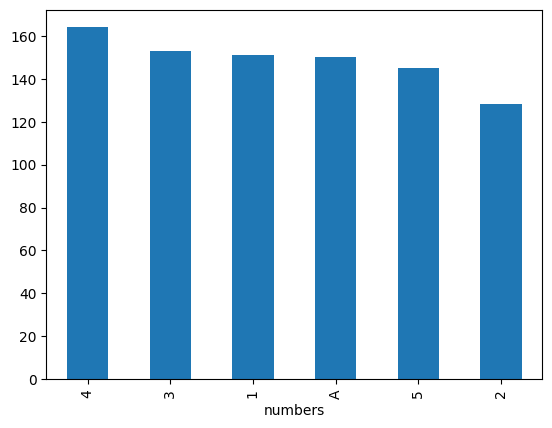

In [13]:
fig = df['numbers'].value_counts().plot(kind='bar')

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
Ticket,0
Cabin,0
Survived,0
numbers,0


In [19]:
# Extract Numeric part of number column
df['No_numeric'] = pd.to_numeric(df['numbers'], errors='coerce',downcast='integer')

In [24]:
# Extract categorical part of number column
df['No_categorical'] = np.where(df['No_numeric'].isnull(),df['numbers'],np.nan)

In [25]:
df.head(5)

,Ticket,Cabin,Survived,numbers,No_numeric,No_categorical
1,PC 17599,C85,1,1,1.0,NaN
3,113803,C123,1,A,NaN,A
6,17463,E46,0,5,5.0,NaN
10,PP 9549,G6,1,3,3.0,NaN
11,113783,C103,1,4,4.0,NaN


In [27]:
df['Cabin'].unique()

array(['C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6', 'C23 C25 C27',
       'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33', 'F G73', 'E31',
       'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101', 'F E69', 'D47',
       'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4', 'A32', 'B4',
       'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35', 'C87', 'B77',
       'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19', 'B49', 'D',
       'C22 C26', 'C106', 'C65', 'E36', 'C54', 'B57 B59 B63 B66', 'C7',
       'E34', 'C32', 'B18', 'C124', 'C91', 'E40', 'T', 'C128', 'D37',
       'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44', 'A34', 'C104',
       'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14', 'B37', 'C30',
       'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38', 'B39', 'B22',
       'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68', 'B41', 'A20',
       'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48', 'E58', 'C126',
       'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63', 'C62 C64',
       'E24

In [30]:
df['Ticket'].unique()

array(['PC 17599', '113803', '17463', 'PP 9549', '113783', '248698',
       '113788', '19950', 'PC 17569', 'PC 17572', '113509', '19947',
       '113572', '36973', 'C.A. 29395', '348123', 'W.E.P. 5734',
       'PC 17754', 'PC 17759', '35281', '110465', 'PC 17558', '27267',
       '2668', '11752', 'PC 17593', '230080', '113776', '113505',
       '111240', '17764', 'PC 17595', '230136', '113767', 'PC 17610',
       '347054', '112277', '35273', '11813', '19943', '19928', '11751',
       '113514', '110152', '110413', '112059', 'PC 17582', 'PC 17760',
       'PC 17596', '13502', '113056', '11967', 'SC/Paris 2163', '113781',
       '19988', '226593', 'PC 17758', 'PC 17485', '11767', 'PC 17608',
       '36928', '16966', '28551', '111361', '113043', '113784', '248733',
       '113510', '110813', 'PC 17477', '11765', '113503', '113760',
       'SOTON/O.Q. 392078', '110564', '13507', '33638', '113786',
       '113051', '17453', '13509', '17464', '19952', '111320',
       'SC/AH Basle 541', '1177

In [36]:
# Cabin Part

df['cabin_no'] = df['Cabin'].str.extract('(\d+)')
df['cabin_cate'] = df['Cabin'].str[0]

df

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_23454/421635622.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_no'] = df['Cabin'].str.extract('(\d+)')


,Ticket,Cabin,Survived,numbers,No_numeric,No_categorical,cabin_no,cabin_cate
1,PC 17599,C85,1,1,1.0,NaN,85,C
3,113803,C123,1,A,NaN,A,123,C
6,17463,E46,0,5,5.0,NaN,46,E
10,PP 9549,G6,1,3,3.0,NaN,6,G
11,113783,C103,1,4,4.0,NaN,103,C
...,...,...,...,...,...,...,...,...
871,11751,D35,1,1,1.0,NaN,35,D
872,695,B51 B53 B55,0,2,2.0,NaN,51,B
879,11767,C50,1,3,3.0,NaN,50,C
887,112053,B42,1,4,4.0,NaN,42,B


In [43]:
# Ticket Part

df['Ticket_num'] = df['Ticket'].str.extract(r'(\d+)')

df['Ticket_cate'] = df['Ticket'].str.extract(r'([A-Za-z/\.]+)')

df

,Ticket,Cabin,Survived,numbers,No_numeric,No_categorical,cabin_no,cabin_cate,Ticket_num,Ticket_cate
1,PC 17599,C85,1,1,1.0,NaN,85,C,17599,PC
3,113803,C123,1,A,NaN,A,123,C,113803,NaN
6,17463,E46,0,5,5.0,NaN,46,E,17463,NaN
10,PP 9549,G6,1,3,3.0,NaN,6,G,9549,PP
11,113783,C103,1,4,4.0,NaN,103,C,113783,NaN
...,...,...,...,...,...,...,...,...,...,...
871,11751,D35,1,1,1.0,NaN,35,D,11751,NaN
872,695,B51 B53 B55,0,2,2.0,NaN,51,B,695,NaN
879,11767,C50,1,3,3.0,NaN,50,C,11767,NaN
887,112053,B42,1,4,4.0,NaN,42,B,112053,NaN
